In [2]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [3]:
from functools import partial

from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary
from statsforecast.models import AutoARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.processing import make_future_dataframe

In [4]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Chapter 10 - Dynamic regression models

The time series models in the previous two chapters allow for the inclusion of information from past observations of a series, but not for the inclusion of other information that may also be relevant. For example, the effects of holidays, competitor activity, changes in the law, the wider economy, or other external variables, may explain some of the historical variation and may lead to more accurate forecasts. On the other hand, the regression models in Chapter 7 allow for the inclusion of a lot of relevant information from predictor variables, but do not allow for the subtle time series dynamics that can be handled with ARIMA models. In this chapter, we consider how to extend ARIMA models in order to allow other information to be included in the models. 

In chapter 7, we considered regression models of the form $$y_t = \beta_0 + \beta_1x_{1,t} + .. + \beta_kx_{k,t} + \epsilon_t$$
* where $y_t$ is a linear function of the $k$ predictor variables ($x_{1,t}, .., x_{k,t}$) and $\epsilon_t$ is usually assumed to be an uncorrelated term (it is white noise). 

> We considered tests such as the `Ljung-Box` test for assessing whether the resulting residuals were significantly correlated.

In this chapter, we will allow the errors from a regression to contain autocorrelation. The error series $\eta_t$ is assumed to follow an ARIMA model. For example, if $\eta_t$ follows an ARIMA(1,1,1) model, we can write $$y_t = \beta_0 + \beta_1x_{1,t} + .. + \beta_kx_{k,t} + \eta_t$$
$$(1-\phi_1 B)(1-B)\eta_t = (1+\theta_1 B)\epsilon_t$$
* where $\epsilon_t$ is a white noise series.

> Notice that the model has two error terms here — the error from the regression model, which we denote by $\eta_t$, and the error from the ARIMA model, which we denote by $\epsilon_t$. Only the ARIMA model errors are assumed to be white noise.

## 10.1 Estimation

When we estimate the parameters from the model, we need to minimise the sum of squared $\epsilon_t$ values. If we minimise the sum of squared $\eta_t$ values instead (which is what would happen if we estimated the regression model ignoring the autocorrelations in the errors), then several problems arise.
1. The estimated coefficients $\hat{\beta_0}, .., \hat{\beta_k}$ are no longer the best estimates, as some information has been ignored in the calculation;
2. Any statistical tests associated with the model (e.g., t-tests on the coefficients) will be incorrect.
3. The AICc values of the fitted models are no longer a good guide as to which is the best model for forecasting.
4. In most cases, the $p$-values associated with the coefficients will be too small, and so some predictor variables will appear to be important when they are not. This is known as “spurious regression”.

> Minimising the sum of squared $\epsilon_t$ values avoids these problems. Alternatively, maximum likelihood estimation can be used; this will give similar estimates of the coefficients.

> An important consideration when estimating a regression with ARMA errors is that all the variables in the model must first be stationary. 

Thus, we first have to check that $y_t$ and all the predictors ($x_{1,t},...,x_{k,t}$) appear to be stationary. If we estimate the model when any of these are non-stationary, the estimated coefficients will not be consistent estimates (and therefore may not be meaningful). One exception to this is the case where non-stationary variables are co-integrated. If there exists a linear combination of the non-stationary $y_t$ and the predictors that is stationary, then the estimated coefficients will be consistent.

We therefore first difference the non-stationary variables in the model. It is often desirable to maintain the form of the relationship between $y_t$ and the predictors, and consequently it is common to difference all the variables if any of them need differencing. The resulting model is then called a “model in differences”, as distinct from a “model in levels”, which is what is obtained when the original data are used without differencing.

If all the variables in the model are stationary, then we only need to consider an ARMA process for the errors. It is easy to see that a regression model with ARIMA errors is equivalent to a regression model in differences with ARMA errors. For example, if the above regression model with ARIMA(1,1,1) errors is differenced we obtain the model $$y'_t = \beta_1 x'_{1,t} + ... + \beta_k x'_{k,t} + \eta'_t,$$
$$(1-\phi_1B)\eta'_t = (1+\theta_1B)\epsilon_t$$
* where $y'_t = y_t - y_{t-1}, x'_{t,i} = x_{t,i} - x-{t-1,i}$ and $\eta'_t = \eta_t - \eta_{t-1}$ which is a regression model in differences with ARMA errors.




## 10.2 Regression with ARIMA errors using `Statforecast`



The class `ARIMA()` will fit a regression model with ARIMA errors if exogenous regressors are included in the dataframe. As introduced in Section 9.5, order specifies the order of the ARIMA error model following the convention (`p, d, q`). If differencing is specified, then the differencing is applied to all variables in the regression model before the model is estimated.

The `AutoARIMA()` can be used to select the best ARIMA model for the errors. Whether differencing is required is determined by applying a KPSS test to the residuals from the regression model estimated using ordinary least squares. If differencing is required, then all variables are differenced and the model re-estimated using maximum likelihood estimation. The final model will be expressed in terms of the original variables, even if it has been estimated using differenced variables.

The `AICc` is calculated for the final model, and this value can be used to determine the best predictors. That is, the procedure should be repeated for all subsets of predictors to be considered, and the model with the lowest AICc value selected.

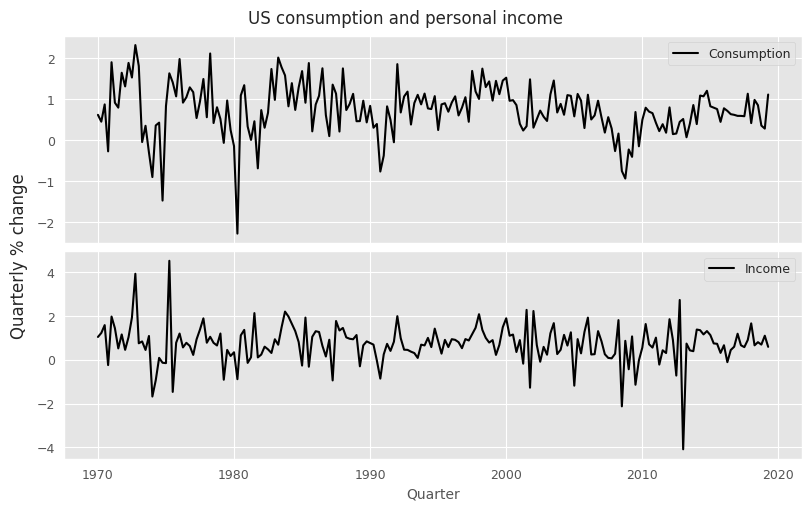

In [5]:
us_change = (
    pd.read_csv(DATA_DIR /'US_change.csv', parse_dates=["ds"])
    .rename(columns={"y": "Consumption"})
    [["unique_id", "ds", "Consumption", "Income"]]
)

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Consumption", color="black",
    label="Consumption", ax=axes[0])
sns.lineplot(data=us_change, x="ds", y="Income", color="black",
    label="Income", ax=axes[1])
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel="Quarter")
fig.supylabel("Quarterly % change")
fig.suptitle("US consumption and personal income")
plt.show()

In [6]:
sf = StatsForecast(models=[AutoARIMA()], freq="QS")
sf = sf.fit(df=us_change, target_col="Consumption")

model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:3]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[3:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(1,0,2) errors 

     ARMA Coefficients
ar1              0.707
ma1             -0.617
ma2              0.207 

           Regression Coefficients
intercept                    0.595
ex_1                         0.198 

         Metrics
sigma^2     0.31
loglik   -163.04
aic       338.07
aicc      338.51
bic       357.80


So, the fitted model is $$y_t 0.595 + 0.198x_t + \eta_t$$, $$\eta_t = 0.707\eta_{t-1} + \epsilon_t - 0.617\epsilon_{t-1} + 0.207\epsilon_{t-2}$$, $$\epsilon_t \sim NID(0, 0,31)$$

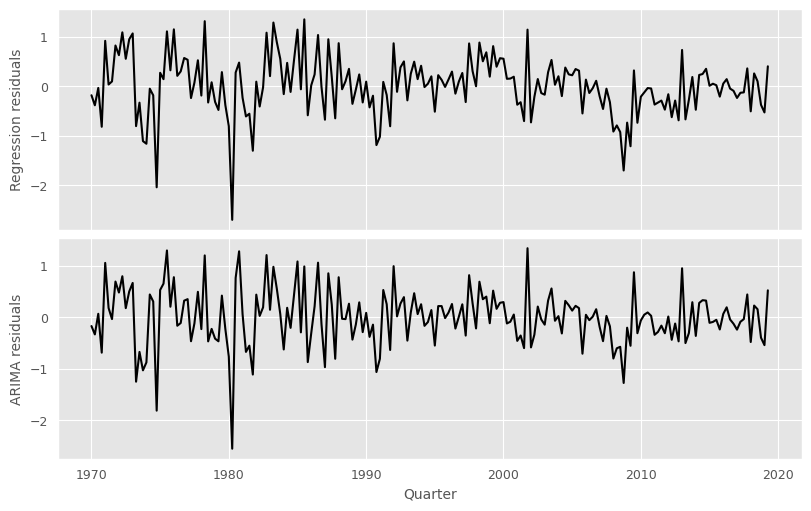

In [7]:
innov_resid = model["residuals"]
reg_resid = (us_change["Consumption"]
    - regr["ex_1"] * us_change["Income"]
    - regr["intercept"])
resid = pd.DataFrame({
    "ARIMA residuals": innov_resid,
    "Regression residuals": reg_resid,
    "ds": us_change["ds"],
})

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=resid, x="ds", y="Regression residuals", color="black",
    ax=axes[0])
sns.lineplot(data=resid, x="ds", y="ARIMA residuals", color="black",
    ax=axes[1])
axes[1].set(xlabel='Quarter')
plt.show()

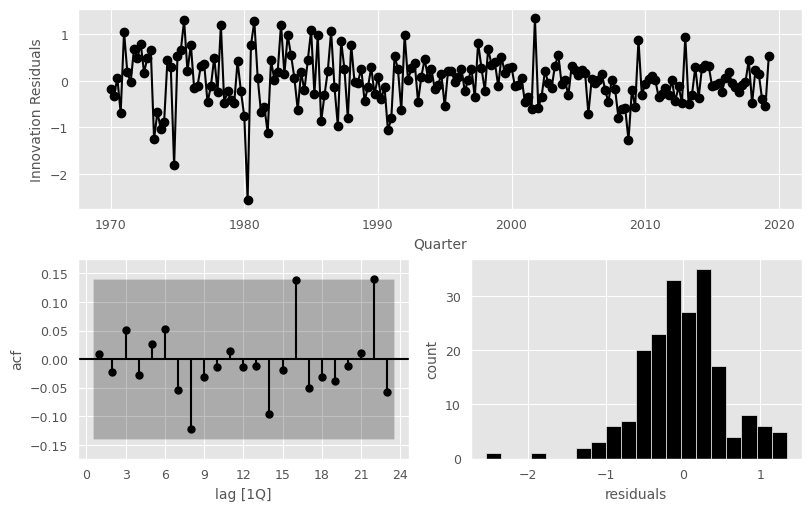

In [8]:
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(resid["ds"], innov_resid, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(innov_resid, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(innov_resid, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [9]:
ljung_box = acorr_ljungbox(innov_resid, lags=[8], model_df=3)
ljung_box

# The innovation residuals (i.e., the estimated ARIMA errors) 
# are not significantly different from white noise.

,lb_stat,lb_pvalue
8,5.207,0.391


# 10.3 Forecasting 

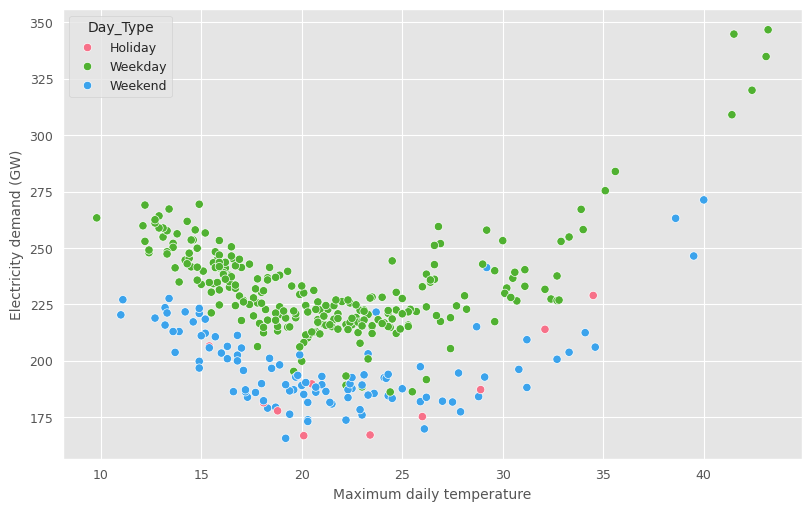

In [18]:
vic_elec = (
    pd.read_csv(DATA_DIR / 'vic_elec.csv', parse_dates=['ds'])
    .loc[lambda x: x["ds"] >= "2014"]
    .pivot(index=["ds", "Holiday"], columns="unique_id", values="y")
    .reset_index(level="Holiday").rename_axis(None, axis="columns")
)
vic_elec_daily = (
    vic_elec
    .resample("D")
    .agg({"Demand": "sum", "Temperature": "max", "Holiday": "first"})
    .reset_index()
    .assign(
        unique_id="VIC",
        Demand=lambda x: x["Demand"] / 1e3,
        Weekend=lambda x: x["ds"].dt.dayofweek.isin([5, 6]),
        Day_Type=lambda x: np.select(
            [x["Holiday"], ~x["Holiday"] & x["Weekend"]],
            ["Holiday", "Weekend"],
            default="Weekday",
        )
    )
)

fig, ax = plt.subplots()
sns.scatterplot(data=vic_elec_daily,
  x="Temperature", y="Demand", hue="Day_Type")
ax.set(
  xlabel="Maximum daily temperature", ylabel="Electricity demand (GW)"
)
plt.show()

The data stored as vic_elec_daily includes total daily demand, daily maximum temperatures, and an indicator variable for if that day is a public holiday. Figure 10.6 shows the time series of both daily demand and daily maximum temperatures. The plots highlight the need for both a non-linear and a dynamic model.

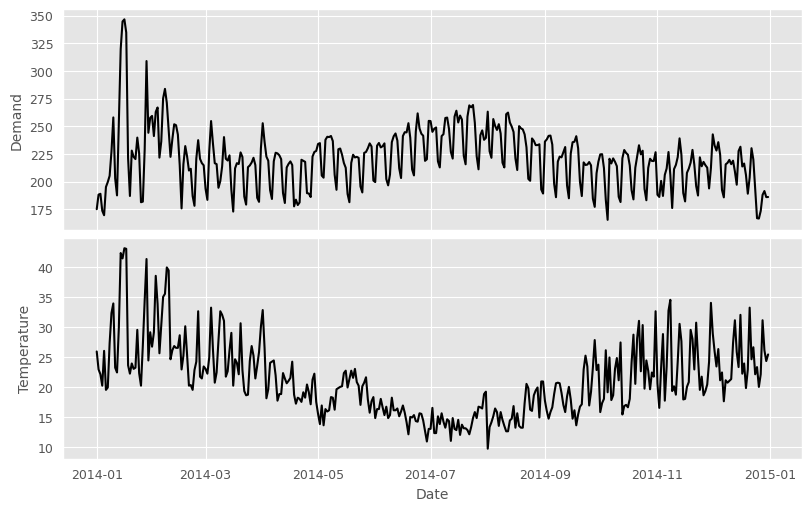

In [12]:
fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=vic_elec_daily, x='ds', y='Demand',
    color='black', ax=axes[0])
sns.lineplot(data=vic_elec_daily, x='ds', y='Temperature',
    color='black', ax=axes[1])
axes[1].set(xlabel="Date")
plt.show()

Daily electricity demand can be modelled as a function of temperature. As can be observed on an electricity bill, more electricity is used on cold days due to heating and hot days due to air conditioning. 

In this example, we fit a quadratic regression model with ARMA errors using the `ARIMA()` function. The model also includes an indicator variable for if the day was a working day or not.

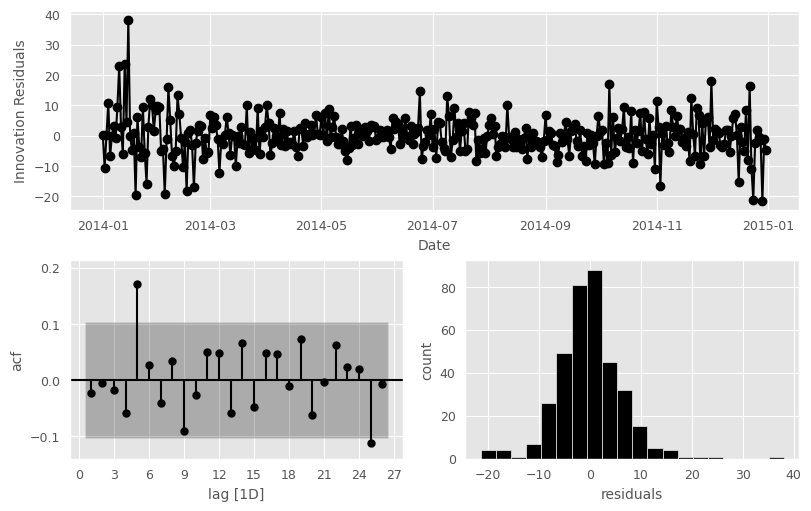

In [13]:
sf = StatsForecast(models=[AutoARIMA(season_length=7)], freq="D")
ex_columns = ["unique_id", "ds", "Demand", "Temperature"]
vic_elec_daily_ex = vic_elec_daily[ex_columns].assign(**{
    "Weekday": vic_elec_daily["Day_Type"] == "Weekday",
    "Temperature**2": vic_elec_daily["Temperature"]**2,
})
sf = sf.fit(df=vic_elec_daily_ex, target_col="Demand")
resids = sf.fitted_[0, 0].model_["residuals"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(vic_elec_daily["ds"], resids, marker="o")
axes["resid"].set(xlabel="Date", ylabel="Innovation Residuals")
plot_acf(resids, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1D]", ylabel="acf", title="")
axes["hist"].hist(resids, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [14]:
model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:8]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[8:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(2,1,2)(2,0,2)[7] errors 

      ARMA Coefficients
ar1              -0.087
ar2               0.716
ma1              -0.024
ma2              -0.914
sar1              0.309
sar2              0.566
sma1             -0.164
sma2             -0.386 

      Regression Coefficients
ex_1                   -7.501
ex_2                   29.325
ex_3                    0.178 

         Metrics
sigma^2    43.06
loglik  -1197.38
aic      2418.77
aicc     2419.66
bic      2465.53


The fitted model has an ARIMA(2,1,2)(2,0,2)[7] error, so there are 8 AR and MA coefficients.



In [15]:
ljung_box = acorr_ljungbox(resids, lags=[14], model_df=8)
ljung_box

,lb_stat,lb_pvalue
14,21.87,0.001


There is clear heteroscedasticity in the residuals, with higher variance in January and February, and lower variance in May. The model also has some significant autocorrelation in the residuals, and the histogram of the residuals shows long tails. All of these issues with the residuals may affect the coverage of the prediction intervals, but the point forecasts should still be ok.

Using the estimated model we forecast 14 days ahead starting from Thursday 1 January 2015 (a non-work-day being a public holiday for New Year’s Day). In this case, we could obtain weather forecasts from the weather bureau for the next 14 days.

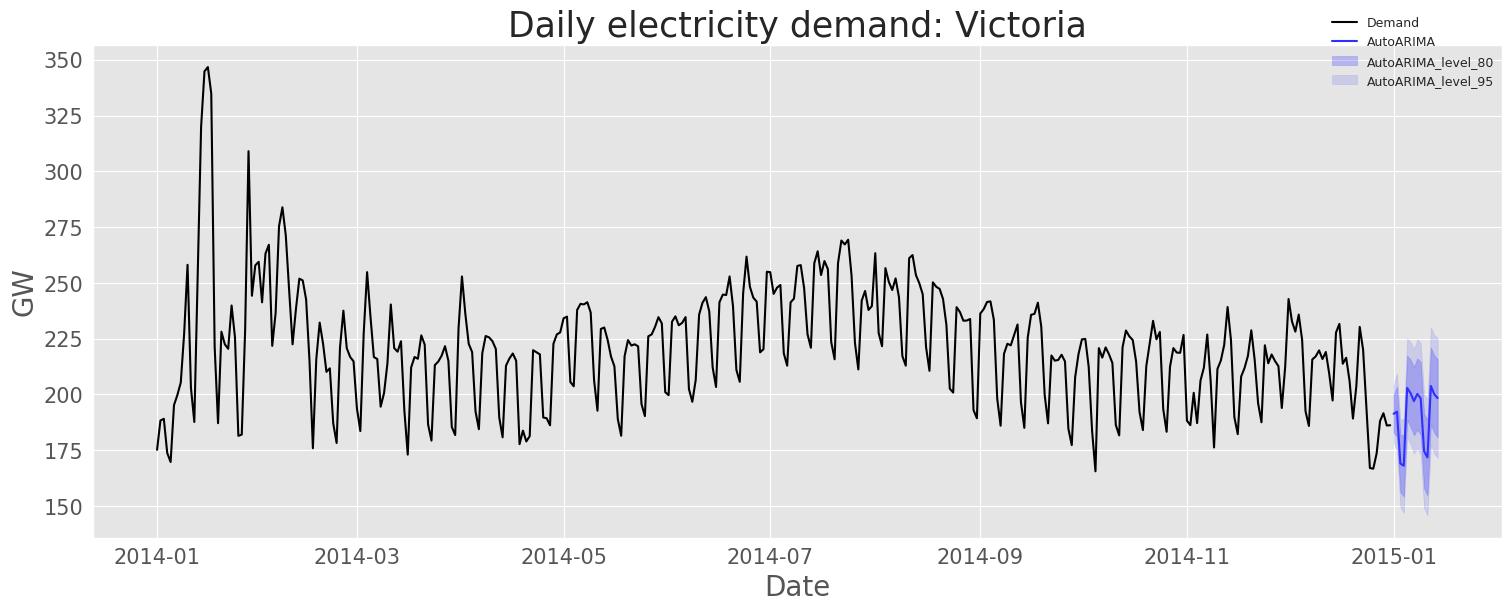

In [17]:
uids = vic_elec_daily_ex["unique_id"].unique()
last_times = vic_elec_daily_ex[["ds"]].max()
future_predictors = (
    make_future_dataframe(uids, last_times, freq="D", h=14)
    .assign(**{
        "Weekday": lambda x: ~x["ds"].dt.dayofweek.isin([5, 6]),
        "Temperature": 26,
        "Temperature**2": 26**2,
    })
)
level = [80, 95]
# Ensure column order agrees with usage above in sf.fit()
columns = vic_elec_daily_ex.columns.drop('Demand')
fc = sf.predict(h=14, X_df=future_predictors[columns], level=level)

plot_series(vic_elec_daily_ex, fc, target_col="Demand", level=level,
    xlabel="Date", ylabel="GW",
    title="Daily electricity demand: Victoria",
    palette="black_and_blue", rm_legend=False,)

Above forecasts from the dynamic regression model for daily electricity demand. All future temperatures have been set to 26 degrees, and the working day dummy variable has been set to known future values.

The point forecasts look reasonable for the first two weeks of 2015. The slow down in electricity demand at the end of 2014 (due to many people taking summer vacations) has caused the forecasts for the next two weeks to show similarly low demand values.

## 10.4 Stochastic and Deterministic trends

When modeling long-term trends, a senior data scientist must choose how the trend evolves over time:  

|Trend Type|Mathematical Form|Forecasting Characteristic|
|--|--|--|
|**Deterministic Trend**|$y_t = \beta_0 + \beta_1 t + \eta_t$  (where $\eta_t$ is ARMA)|Assumes a rigid, unchanging global slope. It produces narrower prediction intervals but is risky if the long-term growth rate shifts.|
|**Stochastic Trend**|$y_t' = y_{t-1} + \beta_1 + \eta_t'$  (where $\eta_t'$ is ARMA and $d=1$)|Behaves like a random walk with drift. It assumes the trend can change over time. It produces much wider prediction intervals, making it safer for long horizons.|

Although these models appear quite similar (they only differ in the number of differences that need to be applied to $\eta_t$), their forecasting characteristics are quite different.


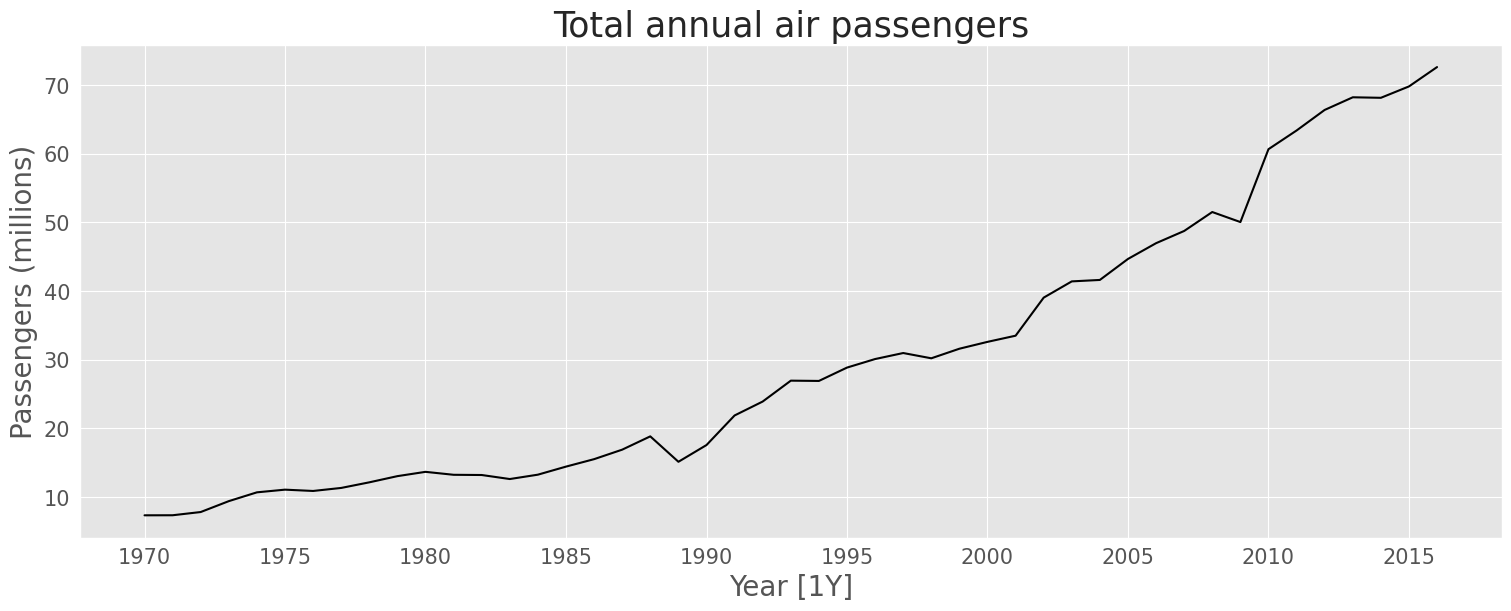

In [19]:
aus_airpassengers = (
    pd.read_csv(DATA_DIR / 'aus_airpassengers.csv', parse_dates=['Year'])
    [['Year', 'Passengers']]
    .rename(columns={'Year':'ds', 'Passengers':'y'})
    .assign(unique_id="aus_airpassengers")
)

plot_series(aus_airpassengers,
    xlabel="Year [1Y]",
    ylabel="Passengers (millions)",
    title="Total annual air passengers",
    palette="black"
)

Figure 10.9 shows the total number of passengers for Australian air carriers each year from 1970 to 2016. We will fit both a deterministic and a stochastic trend model to these data using the trend method from utilsforecast. The deterministic trend model is obtained as follows:

In [21]:
train_df, future_df = trend(aus_airpassengers, freq='YS', h=20)
train_df["intercept"] = 1
future_df["intercept"] = 1
model = AutoARIMA(d=0, alias="AutoARIMA_det")
sf = StatsForecast(models=[model], freq="YS")
sf = sf.fit(df=train_df)
fc_det = sf.predict(h=20, X_df=future_df, level=[80, 95])

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(1,0,0) errors 

      Coefficients
ar1          0.956
ex_1         1.415
ex_2         0.902 

         Metrics
sigma^2     4.34
loglik   -100.88
aic       209.77
aicc      210.72
bic       217.17


This model can be written as $$y_t =0.902 1.1415t + \eta_t$$ 
$$\eta_t = 0.956\eta_{t-1} + \epsilon_t$$
$$\epsilon_t \sim NID(0, 4.34)$$

The estimated growth in visitor numbers is 1.42 million people per year.

Alternatively, the stochastic trend model can be estimated.

In [22]:
model = AutoARIMA(d=1, alias="AutoARIMA_stoch")

sf = StatsForecast(models=[model], freq="YS")
sf = sf.fit(df=aus_airpassengers)
fc_stoch = sf.predict(h=20, level=[80, 95])

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs = pd.Series(coefs, name="Coefficients").round(3)

metrics = pd.Series({
    "sigma^2": model["sigma2"],
    "loglik": model["loglik"],
    "aic": model["aic"],
    "aicc": model["aicc"],
    "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(0,1,0) with drift         

       Coefficients
drift         1.419 

         Metrics
sigma^2     4.27
loglik    -98.16
aic       200.31
aicc      200.59
bic       203.97


This model can be written as $y_t - y_{t-1} = 1.419 + \epsilon_t$, or equivalently $$y_t = y_0 + 1.419t + \eta_t$$
$$\eta_t = \eta_{t-1} + \epsilon_t$$
$$\eta_t \sim NID(0, 4.27)$$

In this case, the estimated growth in visitor numbers is also 1.42 million people per year. Although the growth estimates are similar, the prediction intervals are not, as below Figure shows. In particular, stochastic trends have much wider prediction intervals because the errors are non-stationary.

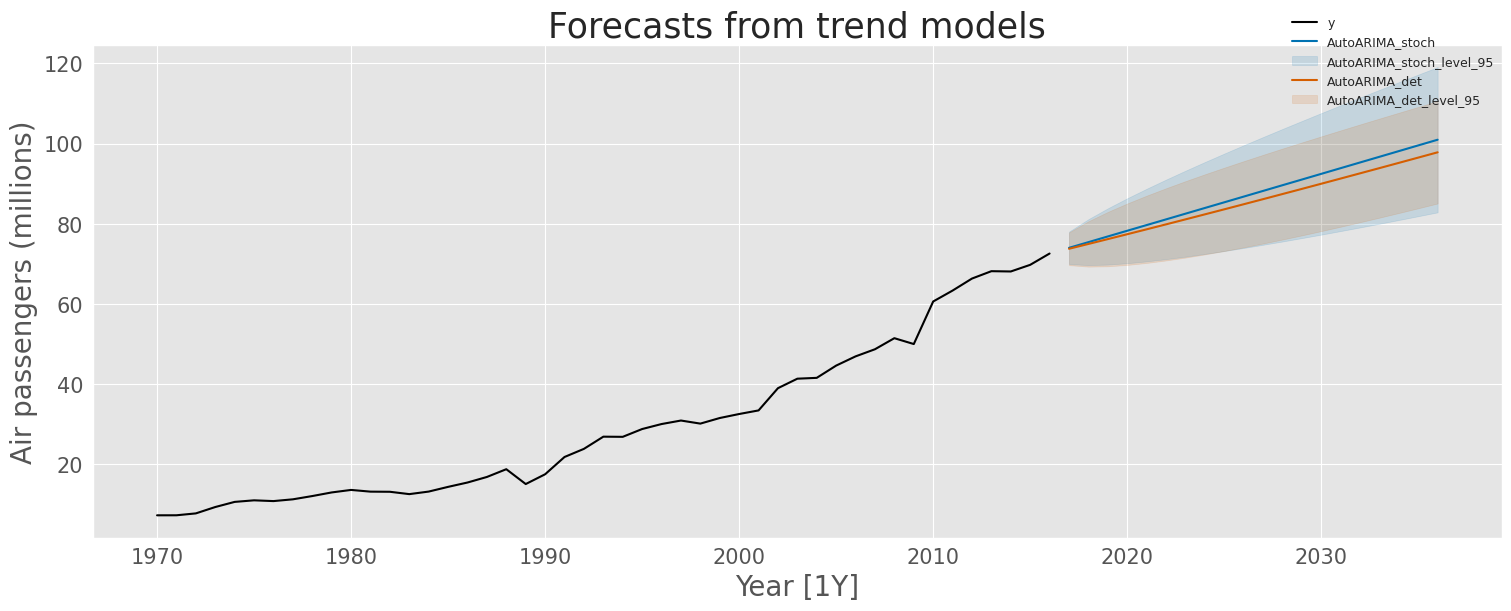

In [24]:
df = fc_stoch.merge(fc_det, on=['unique_id', 'ds'])
plot_series(aus_airpassengers, df, level=[95],
    xlabel="Year [1Y]", ylabel="Air passengers (millions)",
    title="Forecasts from trend models",
    palette="black_and_2color", rm_legend=False,)

There is an implicit assumption with deterministic trends that the slope of the trend is not going to change over time. On the other hand, stochastic trends can change, and the estimated growth is only assumed to be the average growth over the historical period, not necessarily the rate of growth that will be observed into the future. Consequently, it is safer to forecast with stochastic trends, especially for longer forecast horizons.


## 10.5 Dynamic harmonic regresion 

For time series with long seasonal periods (e.g., daily data where $m=365$, or half-hourly data where $m=48$), traditional seasonal ARIMA or ETS models break down because they require estimating too many initial states ($m-1$). Seasonal versions of ARIMA and ETS models are designed for shorter periods such as 12 for monthly data or 4 for quarterly data. 

Dynamic Harmonic Regression solves this by using Fourier terms (sine and cosine pairs) to model the seasonal pattern structurally, leaving the short-term dynamics to an ARMA error process.  

* Advantages:
    * it allows any length seasonality;
    * for data with more than one seasonal period, Fourier terms of different frequencies can be included;
    * the smoothness of the seasonal pattern can be controlled by $K$, K, the number of Fourier sin and cos pairs – the seasonal pattern is smoother for smaller values of $K$;
    * the short-term dynamics are easily handled with a simple ARMA error.
* Disadvantages: It assumes the seasonal pattern is fixed and does not change over time

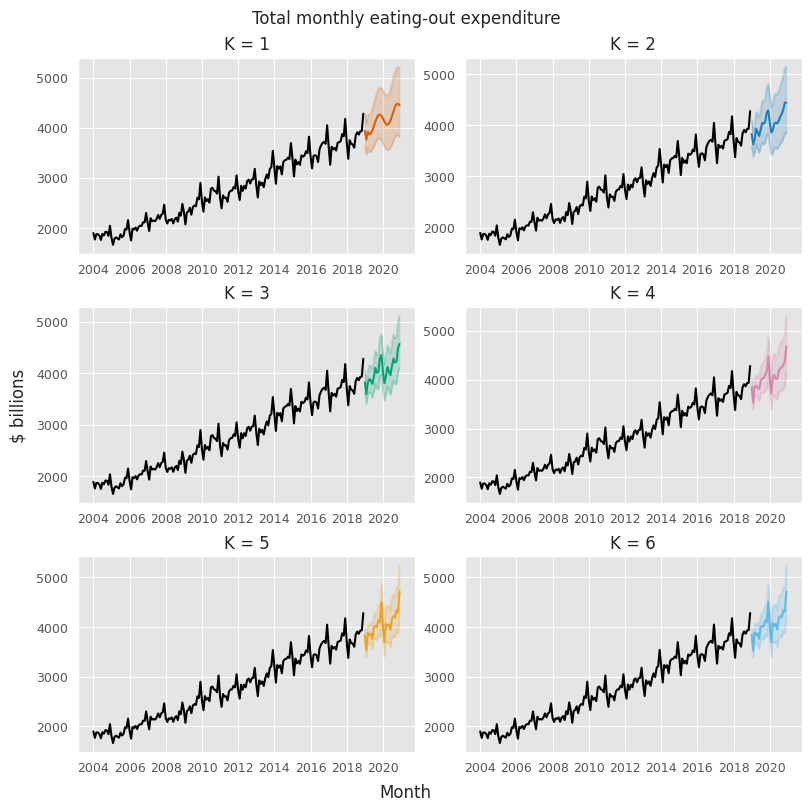

In [26]:
industry = "Cafes, restaurants and takeaway food services"
aus_cafe_df = (
    pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates=["Month"])
    .loc[lambda x: x["Month"].between("2004", "2018-12-01")
        & (x["Industry"] == industry)
    ]
    .rename(columns={"Month": "ds", "Turnover": "y"})
    .groupby("ds", as_index=False)
    .agg({"y": "sum"})
    .assign(unique_id="aus_cafe")
)

def arima_with_fourier(k):
    aus_cafe = aus_cafe_df.assign(y=np.log(aus_cafe_df["y"]))
    features = [partial(fourier, season_length=12, k=k)]
    aus_cafe, fut = pipeline(
        aus_cafe, features=features, freq="MS", h=24)
    model = AutoARIMA(season_length=12, seasonal=False)
    sf = StatsForecast(models=[model], freq="MS")
    result = sf.forecast(df=aus_cafe, h=24, X_df=fut, level=[80, 95])
    numerics = result.select_dtypes(include=np.number)
    result[numerics.columns] = numerics.apply(np.exp)
    result["unique_id"] = "K=" + str(k)
    return result

def plot_with_intervals(ax, result, color):
    lo, mid, hi = "AutoARIMA-lo-95", "AutoARIMA", "AutoARIMA-hi-95"
    sns.lineplot(data=aus_cafe_df, x="ds", y="y", ax=ax, color="black")
    sns.lineplot(data=result, x="ds", y=mid, ax=ax, color=color)
    sns.lineplot(data=result, x="ds", y=lo, ax=ax, color=color, alpha=0.2)
    sns.lineplot(data=result, x="ds", y=hi, ax=ax, color=color, alpha=0.2)
    ax.fill_between(result["ds"], result[lo], result[hi],
        color=color, alpha=0.2)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title("K = " + str(i + 1))

fig, axes = plt.subplots(3, 2, figsize=(8, 8))
colors = ["#d6610a", "#207fb9", "#0aa076", "#d388ac", "#e9a32b", "#62b9e9"]
for i, (ax, color) in enumerate(zip(axes.flat, colors)):
    result = arima_with_fourier(i + 1)
    plot_with_intervals(ax, result, color)
fig.suptitle("Total monthly eating-out expenditure")
fig.supylabel("$ billions")
fig.supxlabel("Month")
plt.show()

## 10.6 Lagged Predictors 

Sometimes, the impact of a predictor will not be simple and immediate. For example, an advertising campaign may impact sales beyond the end of the campaign, and sales in one month will depend on advertising expenditure in each of the past few months. Similarly, a change in a company’s safety policy may reduce accidents immediately, but have a diminishing effect over time as employees take less care as they become familiar with the new working conditions.

In these situations, we need to allow for lagged effects of the predictor. Suppose that we have only one predictor in our model. Then a model which allows for lagged effects can be written as $$y_t = \beta_0 + \gamma_0x_t + \gamma_1x_t  + ... + \gamma_k x_{t-k} + \eta_t$$
* where $\eta_t$ is an ARIMA process. The value of $k$ can be selected using the AICc, along with the values of $p$ and $q$ for the ARIMA error.

Example: TV advertising and insurance quotations

A US insurance company advertises on television in an attempt to increase the number of insurance quotations provided (and consequently the number of new policies).

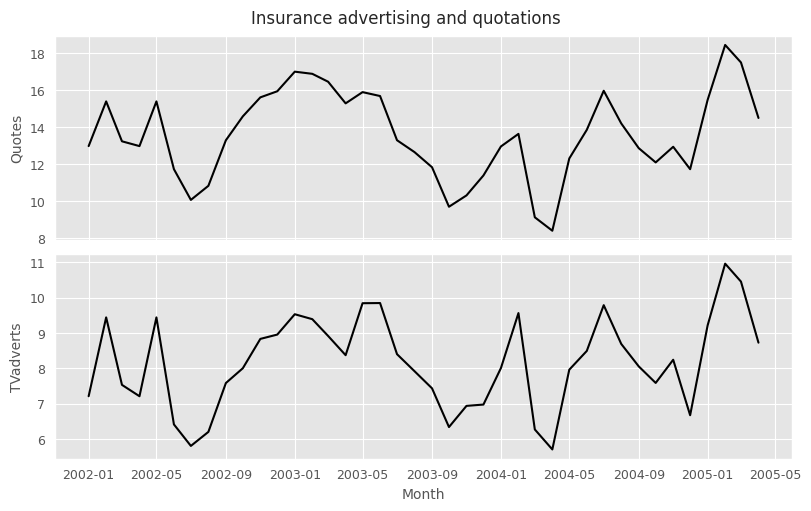

In [27]:
insurance = pd.read_csv(DATA_DIR / "insurance.csv", parse_dates=['ds'])
fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=insurance, x="ds", y="Quotes",
    ax=axes[0], color="black")
sns.lineplot(data=insurance, x='ds', y='TVadverts',
    ax=axes[1], color='black')
axes[1].set(xlabel="Month")
fig.suptitle("Insurance advertising and quotations")
plt.show()

We will consider forecasting quotations using advertising expenditure as a predictor for up to four months; that is, the model may include advertising expenditure in the current month, and the three months before that. When comparing models, it is important that they all use the same training set. In the following code, we exclude the first three months in order to make fair comparisons.

Next we choose the optimal lag length for advertising based on the AICc.

In [28]:
train = (
    insurance.assign(**{
        f"TVadverts_{lag}": insurance["TVadverts"].shift(lag)
        for lag in (1, 2, 3)
    })
    .assign(Quotes=insurance.Quotes.iloc[4:])
)

base_columns = ["unique_id", "ds", "Quotes", "TVadverts"]
lag_columns = ["TVadverts_1", "TVadverts_2", "TVadverts_3"]
model = AutoARIMA(season_length=12, d=0)
sfs = [
    StatsForecast(models=[model], freq='MS').fit(
        df=train[[*base_columns, *lag_columns[:n]]], target_col="Quotes")
    for n in range(4)
]

df = pd.DataFrame([
    {"model": f"lag{i}", "aicc": sf.fitted_[0, 0].model_["aicc"]}
    for (i, sf) in enumerate(sfs)
])
df.round(2)

,model,aicc
0,lag0,66.67
1,lag1,58.43
2,lag2,61.53
3,lag3,64.71


The best model (with the smallest AICc value) is `lag1` with two predictors; that is, it includes advertising only in the current month and the previous month. So we now re-estimate that model, but using all the available data.



In [29]:
fit_df = insurance.assign(**{
    f"TVadverts_{lag}": insurance["TVadverts"].shift(lag)
    for lag in (1, 2, 3)
})
sf = StatsForecast(models=[AutoARIMA(d=0)], freq='MS')
fit_columns = ["unique_id", "ds", "Quotes", "TVadverts", "TVadverts_1"]
sf.fit(df=fit_df[fit_columns].dropna(), target_col="Quotes")

model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:3]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[3:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(1,0,2) errors 

     ARMA Coefficients
ar1              0.512
ma1              0.917
ma2              0.459 

           Regression Coefficients
intercept                    2.155
ex_1                         1.253
ex_2                         0.146 

         Metrics
sigma^2     0.22
loglik    -23.94
aic        61.88
aicc       65.49
bic        73.52


The chosen model has ARIMA(1,0,2) errors. The model can be written as $$y_t = 2.155 + 1.253x_t + 0.146x_{t-1} + \eta_t$$
* where $y_t$ is the number of quotations provided in month $t$, $x_t$ is the advertising expenditure in month $t$. $$\eta_t = 0.512\eta_{t-1} + \epsilon_t + 0.917\epsilon_{t-1} + 0.459\epsilon_{t-2}$$
* and $\epsilon_t$ is white noise. 

We can calculate forecasts using this model if we assume future values for the advertising variable. If we set the future monthly advertising to 8 units

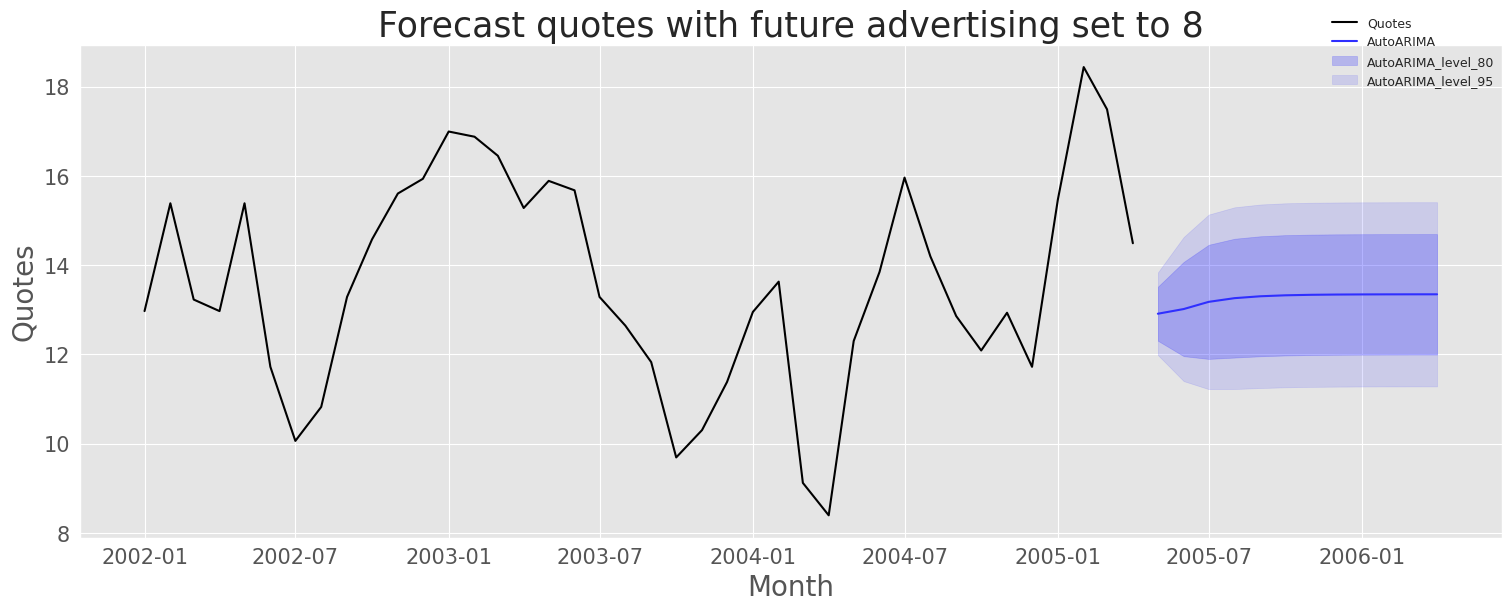

In [31]:
uids = insurance["unique_id"].unique()
last_times = insurance[["ds"]].max()
future_predictors = (
    make_future_dataframe(uids, last_times, freq="MS", h=12)
    .assign(TVadverts=8, TVadverts_1=8)
)
sf.fit(df=fit_df[fit_columns].dropna(), target_col="Quotes")
fc = sf.predict(h=12, X_df=future_predictors, level=[80,95])
plot_series(insurance, fc, level=[80,95], target_col="Quotes",
    xlabel="Month", ylabel="Quotes",
    title="Forecast quotes with future advertising set to 8",
    palette="black_and_blue", rm_legend=False,)

### Advanced forecasting nuances

> When deploying a dynamic regression model to production, you must account for the nature of your prediction intervals.  

> Because the model conditions $y_t$ on $x_t$, the prediction intervals do not factor in the uncertainty of your future predictor forecasts. They assume your future $x_t$ values are perfectly known. If your predictors are themselves unknown future values (like weather or economic indicators), you must model them separately or use scenario-based forecasting (e.g., assessing demand assuming a constant 26°C temperature) to safely interpret the outputs. 